<a href="https://colab.research.google.com/github/Ryan-sfa/Assigment_1/blob/main/assigment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving nlp_customer_support_classification (1).csv to nlp_customer_support_classification (1).csv


In [2]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv("nlp_customer_support_classification (1).csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Dataset Shape:
(800, 12)

Columns:
Index(['message_id', 'text', 'intent_label', 'sentiment', 'urgency_level',
       'classification_confidence', 'channel', 'language', 'word_count',
       'response_time_hours', 'is_resolved', 'csat_score'],
      dtype='object')


,message_id,text,intent_label,sentiment,urgency_level,classification_confidence,channel,language,word_count,response_time_hours,is_resolved,csat_score
0,MSG-1000,Switched to your E-Reader Glow from a competit...,feedback_positive,positive,low,0.811,social_media,de,12,46.3,True,5.0
1,MSG-1001,I need to change the shipping address for my S...,request,neutral,high,0.934,live_chat,en,12,63.8,True,4.0
2,MSG-1002,The Robot Vacuum X overheats when running Musi...,technical_issue,negative,high,0.794,email,es,13,57.6,False,NaN
3,MSG-1003,I need an invoice for my Portable Monitor purc...,request,neutral,medium,0.916,social_media,en,11,5.8,True,4.0
4,MSG-1004,Your FitTrack AI team was incredibly helpful w...,feedback_positive,positive,low,0.841,phone,es,12,52.4,True,5.0


In [5]:
print("Number of classes:")
print(df["intent_label"].nunique())

print("\nClass Distribution:")
print(df["intent_label"].value_counts())

Number of classes:
5

Class Distribution:
intent_label
inquiry              165
feedback_positive    163
technical_issue      159
complaint            159
request              154
Name: count, dtype: int64


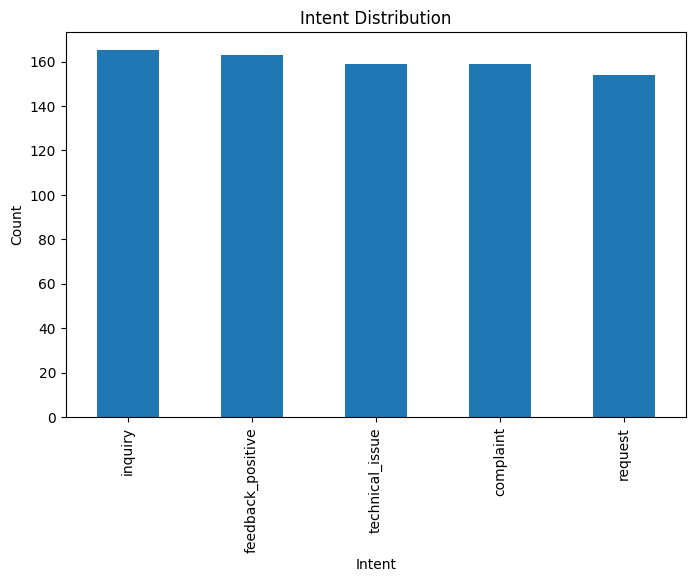

In [6]:
plt.figure(figsize=(8,5))

df["intent_label"].value_counts().plot(
    kind="bar"
)

plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")

plt.show()

In [7]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^\w\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

df["text"] = df["text"].apply(clean_text)

df.head()

,message_id,text,intent_label,sentiment,urgency_level,classification_confidence,channel,language,word_count,response_time_hours,is_resolved,csat_score
0,MSG-1000,switched to your ereader glow from a competito...,feedback_positive,positive,low,0.811,social_media,de,12,46.3,True,5.0
1,MSG-1001,i need to change the shipping address for my s...,request,neutral,high,0.934,live_chat,en,12,63.8,True,4.0
2,MSG-1002,the robot vacuum x overheats when running musi...,technical_issue,negative,high,0.794,email,es,13,57.6,False,NaN
3,MSG-1003,i need an invoice for my portable monitor purc...,request,neutral,medium,0.916,social_media,en,11,5.8,True,4.0
4,MSG-1004,your fittrack ai team was incredibly helpful w...,feedback_positive,positive,low,0.841,phone,es,12,52.4,True,5.0


In [8]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["intent_label"]
)

print("Classes:")
print(encoder.classes_)

Classes:
['complaint' 'feedback_positive' 'inquiry' 'request' 'technical_issue']


In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 560
Validation: 120
Test: 120


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS
)

tokenizer.fit_on_texts(
    train_texts
)

X_train = tokenizer.texts_to_sequences(
    train_texts
)

X_val = tokenizer.texts_to_sequences(
    val_texts
)

X_test = tokenizer.texts_to_sequences(
    test_texts
)

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN
)

X_val = pad_sequences(
    X_val,
    maxlen=MAX_LEN
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN
)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

num_classes = len(
    encoder.classes_
)

lstm_model = Sequential([

    Embedding(
        MAX_WORDS,
        128
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = lstm_model.fit(
    X_train,
    train_labels,
    validation_data=(
        X_val,
        val_labels
    ),
    epochs=10,
    batch_size=32
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.2554 - loss: 1.6017 - val_accuracy: 0.2500 - val_loss: 1.5531
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5161 - loss: 1.3958 - val_accuracy: 0.5500 - val_loss: 1.0188
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8250 - loss: 0.8082 - val_accuracy: 0.8417 - val_loss: 0.4950
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9446 - loss: 0.2862 - val_accuracy: 1.0000 - val_loss: 0.0476
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9964 - loss: 0.0489 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 7.3441e-04
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000

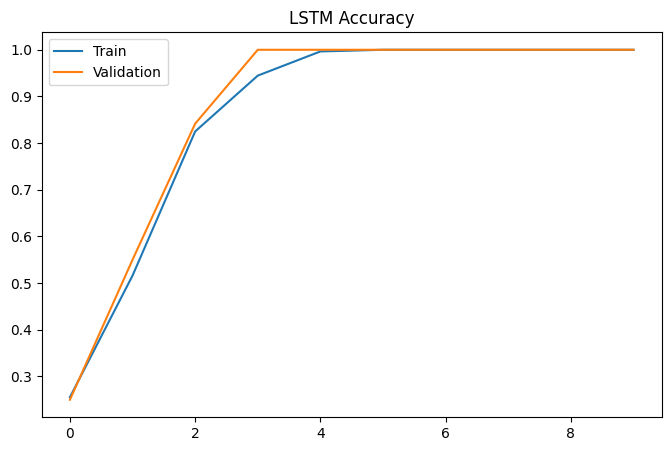

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.title(
    "LSTM Accuracy"
)

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [14]:
pred_probs = lstm_model.predict(
    X_test
)

lstm_preds = np.argmax(
    pred_probs,
    axis=1
)

print(
    classification_report(
        test_labels,
        lstm_preds,
        target_names=encoder.classes_
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
                   precision    recall  f1-score   support

        complaint       1.00      1.00      1.00        24
feedback_positive       1.00      1.00      1.00        25
          inquiry       1.00      1.00      1.00        24
          request       1.00      1.00      1.00        23
  technical_issue       1.00      1.00      1.00        24

         accuracy                           1.00       120
        macro avg       1.00      1.00      1.00       120
     weighted avg       1.00      1.00      1.00       120



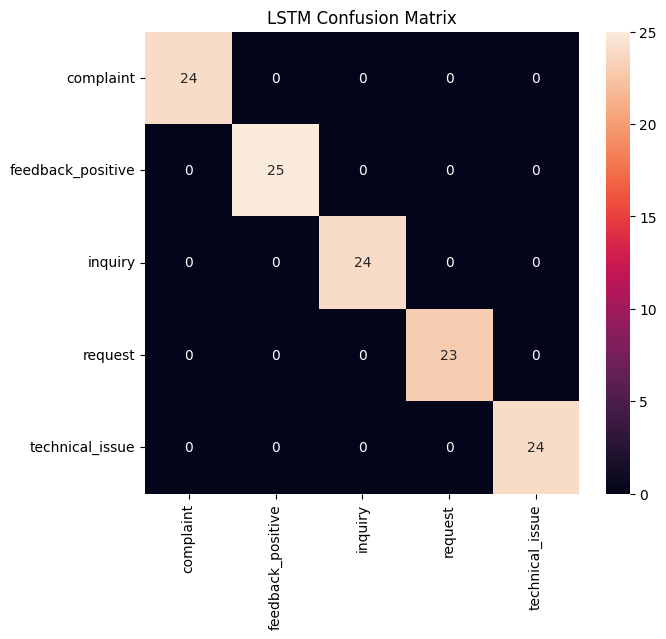

In [15]:
cm = confusion_matrix(
    test_labels,
    lstm_preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "LSTM Confusion Matrix"
)

plt.show()

In [16]:
from datasets import Dataset

train_ds = Dataset.from_dict({
    "text": list(train_texts),
    "label": list(train_labels)
})

val_ds = Dataset.from_dict({
    "text": list(val_texts),
    "label": list(val_labels)
})

test_ds = Dataset.from_dict({
    "text": list(test_texts),
    "label": list(test_labels)
})

In [17]:
from transformers import DistilBertTokenizer

bert_tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
def tokenize(batch):

    return bert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(
    tokenize,
    batched=True
)

val_ds = val_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/560 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

In [19]:
from transformers import DistilBertForSequenceClassification

bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16
)

In [21]:
import evaluate

accuracy_metric = evaluate.load(
    "accuracy"
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

In [22]:
from transformers import Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.942799,1.000000
2,No log,0.377926,1.000000
3,No log,0.249178,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=105, training_loss=0.788554454985119, metrics={'train_runtime': 41.4507, 'train_samples_per_second': 40.53, 'train_steps_per_second': 2.533, 'total_flos': 55639284019200.0, 'train_loss': 0.788554454985119, 'epoch': 3.0})

In [23]:
predictions = trainer.predict(
    test_ds
)

bert_preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        test_labels,
        bert_preds,
        target_names=encoder.classes_
    )
)

                   precision    recall  f1-score   support

        complaint       1.00      1.00      1.00        24
feedback_positive       1.00      1.00      1.00        25
          inquiry       1.00      1.00      1.00        24
          request       1.00      1.00      1.00        23
  technical_issue       1.00      1.00      1.00        24

         accuracy                           1.00       120
        macro avg       1.00      1.00      1.00       120
     weighted avg       1.00      1.00      1.00       120



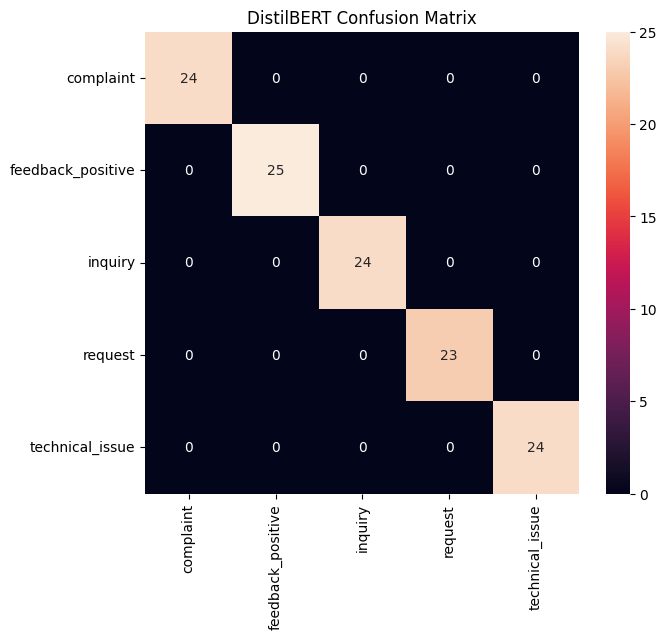

In [24]:
cm = confusion_matrix(
    test_labels,
    bert_preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "DistilBERT Confusion Matrix"
)

plt.show()

In [25]:
errors = []

for text, true, pred in zip(
    test_texts,
    test_labels,
    bert_preds
):

    if true != pred:

        errors.append([
            text,
            encoder.inverse_transform([true])[0],
            encoder.inverse_transform([pred])[0]
        ])

error_df = pd.DataFrame(
    errors,
    columns=[
        "Text",
        "Actual",
        "Predicted"
    ]
)

error_df.head(10)

,Text,Actual,Predicted
